# Project: Using Cascade Models to Reduce Inference Times and the Resource Usage in Edge Computing Scenarios 
---

### @author Houda Mesly
---

### Question 2 - Assessing Confidence in Regression Tasks  
#### Gaussian NLL, Heteroscedastic Uncertainty, and a Toy 1D Example

In this question, we examine how to quantify the **confidence** of a regression model's prediction.  
We follow the approach introduced in the course slides, where a neural network predicts both:

- a **mean** value  
- an **input-dependent variance**

and is trained using the **Gaussian Negative Log-Likelihood (NLL)**.  
This allows the model to express **heteroscedastic uncertainty**, i.e., uncertainty that varies across the input space.

To illustrate the method, we construct a **1D toy dataset** with **non-uniform noise** and train a heteroscedastic model to recover both the mean function and the spatially varying uncertainty.  
The predicted standard deviation **σ(x)** serves as a confidence score for later cascade decisions.

Finally, we briefly introduce **quantile regression** as an alternative, distribution-free way of estimating predictive intervals and confidence.

---


##### Imports and Dataset Generation

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

#### Generate a 1D Toy Dataset

We construct a simple regression dataset defined by:

$$
y = \sin(x) + \text{noise}(x)
$$

where the noise level is **heteroscedastic**:

- **Low noise** for $x < 0$  
- **High noise** for $x \ge 0$

This setup allows us to test whether a Gaussian NLL model can learn both the underlying function and the input-dependent uncertainty.


In [ ]:
def generate_heteroscedastic_data(n_samples=500):
    # sample x uniformly from [-3, 3]
    x = np.random.uniform(-3.0, 3.0, size=(n_samples, 1))
    x = np.sort(x, axis=0)

    # true underlying function
    y_clean = np.sin(x)

    # heteroscedastic noise: smaller on the left, larger on the right
    noise_std = np.where(x < 0, 0.1, 0.5)
    noise = np.random.normal(loc=0.0, scale=noise_std)

    y = y_clean + noise

    return x.astype(np.float32), y.astype(np.float32), noise_std.astype(np.float32)

# generating data
X_np, y_np, noise_std_np = generate_heteroscedastic_data(n_samples=500)

# train / test split
n_train = int(0.8 * len(X_np))
X_train_np, X_test_np = X_np[:n_train], X_np[n_train:]
y_train_np, y_test_np = y_np[:n_train], y_np[n_train:]

# convert to torch tensors
X_train = torch.from_numpy(X_train_np)
y_train = torch.from_numpy(y_train_np).squeeze(-1)  # [N]
X_test = torch.from_numpy(X_test_np)
y_test = torch.from_numpy(y_test_np).squeeze(-1)

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)


torch.Size([400, 1]) torch.Size([400]) torch.Size([100, 1]) torch.Size([100])


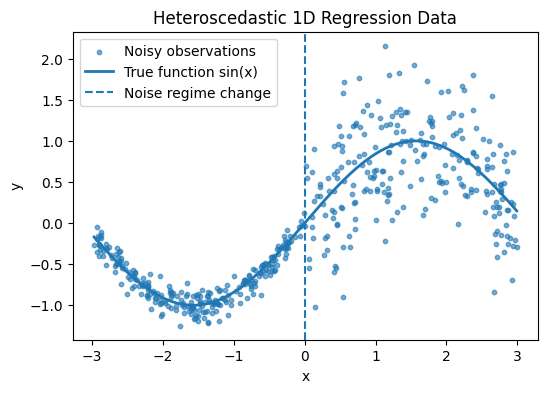

In [3]:
plt.figure(figsize=(6,4))
plt.scatter(X_np, y_np, s=10, alpha=0.6, label="Noisy observations")
plt.plot(X_np, np.sin(X_np), linewidth=2, label="True function sin(x)")
plt.axvline(0, linestyle="--", label="Noise regime change")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Heteroscedastic 1D Regression Data")
plt.show()

#### Model Definition: Outputs Mean and Log-Variance

In [ ]:
class HeteroscedasticRegressor(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh()
        )
        # heads: one for mean, one for log-variance
        self.mean_head = nn.Linear(hidden_dim, 1)
        self.log_var_head = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        """
        x: [N, 1]
        returns:
          mu: [N]
          log_var: [N]
        """
        h = self.net(x)
        mu = self.mean_head(h).squeeze(-1)
        log_var = self.log_var_head(h).squeeze(-1)
        return mu, log_var


In [5]:
model = HeteroscedasticRegressor(input_dim=1, hidden_dim=32)

optimizer = optim.Adam(model.parameters(), lr=1e-3)


##### Gaussian Negative log likelihood loss for 1D Regression

The Gaussian NLL loss is defined as:

`L = 0.5 * ( log_var + (y - mu)^2 / exp(log_var) )`

where:

- `mu` is the predicted mean  
- `log_var` is the predicted log-variance  

The loss is averaged over the batch.


In [ ]:
def gaussian_nll(y_true, mu, log_var):
    # clamp log_var to avoid numerical issues
    log_var = torch.clamp(log_var, min=-10.0, max=10.0)
    inv_var = torch.exp(-log_var)

    nll = 0.5 * (log_var + (y_true - mu)**2 * inv_var)
    return nll.mean()

#### Training Loop

In [ ]:
n_epochs = 3000
print_interval = 300

for epoch in range(1, n_epochs + 1):
    model.train()
    optimizer.zero_grad()

    mu, log_var = model(X_train)
    loss = gaussian_nll(y_train, mu, log_var)

    loss.backward()
    optimizer.step()

    if epoch % print_interval == 0 or epoch == 1:
        # evaluate on test set to monitor performance
        model.eval()
        with torch.no_grad():
            mu_test, log_var_test = model(X_test)
            test_loss = gaussian_nll(y_test, mu_test, log_var_test).item()

        print(f"Epoch {epoch:4d} | Train NLL: {loss.item():.4f} | Test NLL: {test_loss:.4f}")


Epoch    1 | Train NLL: 0.0968 | Test NLL: 0.2397
Epoch  300 | Train NLL: -1.1263 | Test NLL: 0.0617
Epoch  600 | Train NLL: -1.1719 | Test NLL: 0.0426
Epoch  900 | Train NLL: -1.2006 | Test NLL: 0.0561
Epoch 1200 | Train NLL: -1.2070 | Test NLL: 0.0395
Epoch 1500 | Train NLL: -1.2093 | Test NLL: 0.0340
Epoch 1800 | Train NLL: -1.2111 | Test NLL: 0.0392
Epoch 2100 | Train NLL: -1.2129 | Test NLL: 0.0485
Epoch 2400 | Train NLL: -1.2148 | Test NLL: 0.0597
Epoch 2700 | Train NLL: -1.2174 | Test NLL: 0.0728
Epoch 3000 | Train NLL: -1.2207 | Test NLL: 0.0831


#### Inspecting Mean and Uncertainty

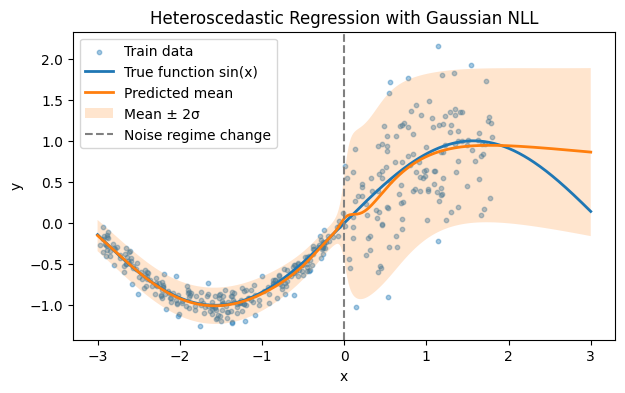

In [ ]:
model.eval()
with torch.no_grad():
    x_grid = np.linspace(-3, 3, 400, dtype=np.float32).reshape(-1, 1)
    x_grid_t = torch.from_numpy(x_grid)
    mu_grid, log_var_grid = model(x_grid_t)
    mu_grid = mu_grid.numpy()
    log_var_grid = log_var_grid.numpy()
    sigma_grid = np.sqrt(np.exp(log_var_grid))


plt.figure(figsize=(7,4))
plt.scatter(X_train_np, y_train_np, s=10, alpha=0.4, label="Train data")
plt.plot(x_grid, np.sin(x_grid), label="True function sin(x)", linewidth=2)


plt.plot(x_grid, mu_grid, label="Predicted mean", linewidth=2)


upper = mu_grid + 2 * sigma_grid
lower = mu_grid - 2 * sigma_grid
plt.fill_between(
    x_grid.squeeze(),
    lower.squeeze(),
    upper.squeeze(),
    alpha=0.2,
    label="Mean ± 2σ"
)

plt.axvline(0, linestyle="--", color="gray", label="Noise regime change")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Heteroscedastic Regression with Gaussian NLL")
plt.legend()
plt.show()


##### Quick Numerical Check of Confidence

In [9]:
test_points = np.array([[-2.0], [-1.0], [0.0], [1.0], [2.0]], dtype=np.float32)
test_points_t = torch.from_numpy(test_points)

model.eval()
with torch.no_grad():
    mu_tp, log_var_tp = model(test_points_t)
    sigma_tp = torch.sqrt(torch.exp(log_var_tp))

for x_val, mu_val, sig_val in zip(test_points, mu_tp, sigma_tp):
    print(f"x = {x_val[0]: .1f} | mu ≈ {mu_val.item(): .3f} | sigma ≈ {sig_val.item(): .3f}")


x = -2.0 | mu ≈ -0.918 | sigma ≈  0.106
x = -1.0 | mu ≈ -0.860 | sigma ≈  0.104
x =  0.0 | mu ≈  0.054 | sigma ≈  0.253
x =  1.0 | mu ≈  0.809 | sigma ≈  0.502
x =  2.0 | mu ≈  0.940 | sigma ≈  0.472


### Question 3 - Training Small and Large Models on the Income Dataset  
#### Data Loading & Preprocessing

In this question, we train two probabilistic regression models on the ACS Income dataset:

- **Small model:** a linear regression model with heteroscedastic confidence  
- **Large model:** a multilayer perceptron (MLP) with confidence (Gaussian NLL)

Both models output a predictive mean **μ(x)** and an input-dependent uncertainty **σ(x)**.

---

In [ ]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from folktables import ACSDataSource, ACSIncome

In [ ]:
data_source = ACSDataSource(
    survey_year='2018',
    horizon='1-Year',
    survey='person'
)

In [12]:
all_states = [
    'AL','AK','AZ','AR','CA','CO','CT','DE','FL','GA',
    'HI','ID','IL','IN','IA','KS','KY','LA','ME','MD',
    'MA','MI','MN','MS','MO','MT','NE','NV','NH','NJ',
    'NM','NY','NC','ND','OH','OK','OR','PA','RI','SC',
    'SD','TN','TX','UT','VT','VA','WA','WV','WI','WY'
]

acs_data = data_source.get_data(
    states=all_states,
    download=True
)

print("Raw ACS dataframe shape:", acs_data.shape)


Raw ACS dataframe shape: (3207990, 286)


#### Data Loading and Preprocessing (ACS Income Dataset)



In [ ]:
# extract features and target
feature_cols = ACSIncome.features      # 10 features in our folktables version
target_col = 'PINCP'

X_all = acs_data[feature_cols].to_numpy().astype(np.float32)
y_all = acs_data[target_col].to_numpy().astype(np.float32)

print("Original feature matrix shape:", X_all.shape)
print("Original income stats (PINCP):")
print("  min:", np.nanmin(y_all), "max:", np.nanmax(y_all))

# build mask for valid rows (no NaNs in features or target)
valid_mask = (~np.isnan(y_all)) & (~np.isnan(X_all).any(axis=1))

X = X_all[valid_mask]
y_raw = y_all[valid_mask]

print("After NaN filtering:")
print("  X shape:", X.shape)
print("  y_raw stats: min =", y_raw.min(), "max =", y_raw.max())

# clamp negative incomes to zero
y_raw = np.clip(y_raw, a_min=0.0, a_max=None)

# log-transform income
y = np.log1p(y_raw).astype(np.float32)
print("Example log-income values:", y[:5])

# train/val/test split (80/10/10)
X_train_np, X_temp_np, y_train_np, y_temp_np = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_val_np, X_test_np, y_val_np, y_test_np = train_test_split(
    X_temp_np, y_temp_np, test_size=0.5, random_state=42
)

print("Train shape:", X_train_np.shape)
print("Val shape:", X_val_np.shape)
print("Test shape:", X_test_np.shape)

# normalize features
scaler = StandardScaler()
X_train_np = scaler.fit_transform(X_train_np)
X_val_np   = scaler.transform(X_val_np)
X_test_np  = scaler.transform(X_test_np)

# convert to torch tensors
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

X_train = torch.from_numpy(X_train_np).float().to(device)
X_val   = torch.from_numpy(X_val_np).float().to(device)
X_test  = torch.from_numpy(X_test_np).float().to(device)

y_train = torch.from_numpy(y_train_np).float().to(device)
y_val   = torch.from_numpy(y_val_np).float().to(device)
y_test  = torch.from_numpy(y_test_np).float().to(device)

# dataLoaders
batch_size = 4096 
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)


Original feature matrix shape: (3207990, 10)
Original income stats (PINCP):
  min: -11200.0 max: 1.423e+06
After NaN filtering:
  X shape: (1669023, 10)
  y_raw stats: min = -11200.0 max = 1.423e+06
Example log-income values: [ 7.3783836  9.210441  10.085851   5.198497  10.275085 ]
Train shape: (1335218, 10)
Val shape: (166902, 10)
Test shape: (166903, 10)
Using device: cpu


#### Gaussian NLL Loss & Model Evaluation

We define the Gaussian Negative Log-Likelihood (NLL) used for heteroscedastic 
regression, where the model predicts both a mean and a log-variance. The evaluation 
function reports two key metrics on any dataset split:  
- **MSE** using only the predicted mean, and  
- **average predicted σ**, indicating the model’s overall uncertainty level.


In [ ]:
def gaussian_nll(y_true, mu, log_var):
    
    # Gaussian NLL loss for 1D regression:
    #     L = 0.5 * (log_var + (y - mu)^2 / exp(log_var))

    log_var = torch.clamp(log_var, min=-10.0, max=10.0)
    inv_var = torch.exp(-log_var)
    nll = 0.5 * (log_var + (y_true - mu)**2 * inv_var)
    return nll.mean()


@torch.no_grad()
def evaluate_model(model, data_loader):
    model.eval()
    total_sq_error = 0.0
    total_count = 0
    sigmas = []

    for xb, yb in data_loader:
        mu, log_var = model(xb)
        sq_error = (yb - mu)**2
        total_sq_error += sq_error.sum().item()
        total_count += yb.numel()

        sigma = torch.sqrt(torch.exp(log_var))
        sigmas.append(sigma.detach().cpu())

    mse = total_sq_error / total_count
    avg_sigma = torch.cat(sigmas).mean().item()
    return mse, avg_sigma


#### Small Model: Linear Regression + Confidence

We define a baseline model: a linear regressor that predicts both the mean 
$ \mu(x) $ and the log-variance $ \log \sigma^2(x) $.  
With no hidden layers, this model is extremely fast and serves as the lightweight 
first stage of the cascade.


In [16]:
class SmallLinearModel(nn.Module):
    """
    Small model: linear regression for mean and log-variance.
    No hidden layers.
    """
    def __init__(self, input_dim):
        super().__init__()
        self.mean_layer = nn.Linear(input_dim, 1)
        self.log_var_layer = nn.Linear(input_dim, 1)

    def forward(self, x):
        """
        x: [N, D]
        returns:
          mu: [N]
          log_var: [N]
        """
        mu = self.mean_layer(x).squeeze(-1)
        log_var = self.log_var_layer(x).squeeze(-1)
        return mu, log_var


In [ ]:
def train_model(model, train_loader, val_loader, n_epochs=10, lr=1e-3):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(1, n_epochs + 1):
        model.train()
        running_loss = 0.0
        n_samples = 0

        for xb, yb in train_loader:
            optimizer.zero_grad()
            mu, log_var = model(xb)
            loss = gaussian_nll(yb, mu, log_var)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * yb.size(0)
            n_samples += yb.size(0)

        train_loss = running_loss / n_samples

        # validation NLL
        model.eval()
        with torch.no_grad():
            val_loss = 0.0
            n_val = 0
            for xb, yb in val_loader:
                mu, log_var = model(xb)
                loss = gaussian_nll(yb, mu, log_var)
                val_loss += loss.item() * yb.size(0)
                n_val += yb.size(0)
            val_loss /= n_val

        if epoch == 1 or epoch % max(1, n_epochs // 10) == 0:
            print(f"[Epoch {epoch:3d}] Train NLL: {train_loss:.4f} | Val NLL: {val_loss:.4f}")

    return model


In [ ]:
input_dim = X_train.shape[1]
print("Input dim:", input_dim)

small_model = SmallLinearModel(input_dim=input_dim)
print("Training SMALL linear model...")
small_model = train_model(small_model, train_loader, val_loader, n_epochs=15, lr=1e-3)

# eval on test set
small_test_mse, small_test_sigma = evaluate_model(small_model, test_loader)
print(f"\n[Small model] Test MSE (log-income): {small_test_mse:.4f}")
print(f"[Small model] Mean predicted sigma (log-income): {small_test_sigma:.4f}")


Input dim: 10
Training SMALL linear model...
[Epoch   1] Train NLL: 34.2571 | Val NLL: 27.4283
[Epoch   2] Train NLL: 23.5737 | Val NLL: 20.2206
[Epoch   3] Train NLL: 17.5611 | Val NLL: 15.1103
[Epoch   4] Train NLL: 13.0877 | Val NLL: 11.2841
[Epoch   5] Train NLL: 10.0802 | Val NLL: 9.0481
[Epoch   6] Train NLL: 8.2556 | Val NLL: 7.4916
[Epoch   7] Train NLL: 6.8682 | Val NLL: 6.2665
[Epoch   8] Train NLL: 5.7765 | Val NLL: 5.3088
[Epoch   9] Train NLL: 4.9350 | Val NLL: 4.5842
[Epoch  10] Train NLL: 4.3100 | Val NLL: 4.0538
[Epoch  11] Train NLL: 3.8536 | Val NLL: 3.6630
[Epoch  12] Train NLL: 3.5117 | Val NLL: 3.3631
[Epoch  13] Train NLL: 3.2431 | Val NLL: 3.1220
[Epoch  14] Train NLL: 3.0234 | Val NLL: 2.9223
[Epoch  15] Train NLL: 2.8401 | Val NLL: 2.7547

[Small model] Test MSE (log-income): 82.1782
[Small model] Mean predicted sigma (log-income): 4.8096


#### Large Model: MLP + Confidence

The large model is a deeper MLP with multiple hidden layers. It predicts both the mean $ \mu(x) $ and the log-variance $ \log \sigma^2(x) $, 
providing a more expressive and accurate second stage for the cascade. Its larger capacity allows it to model complex nonlinear relationships in the data.


In [19]:
class LargeMLPModel(nn.Module):
    """
    Large model: MLP with several hidden layers.
    Still outputs mean and log-variance.
    """
    def __init__(self, input_dim, hidden_dims=(128, 64, 32)):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.ReLU())
            prev_dim = h
        self.backbone = nn.Sequential(*layers)
        self.mean_head = nn.Linear(prev_dim, 1)
        self.log_var_head = nn.Linear(prev_dim, 1)

    def forward(self, x):
        h = self.backbone(x)
        mu = self.mean_head(h).squeeze(-1)
        log_var = self.log_var_head(h).squeeze(-1)
        return mu, log_var


In [20]:
large_model = LargeMLPModel(input_dim=input_dim, hidden_dims=(256, 128, 64))
print("Training LARGE MLP model...")
large_model = train_model(large_model, train_loader, val_loader, n_epochs=15, lr=1e-3)

large_test_mse, large_test_sigma = evaluate_model(large_model, test_loader)
print(f"\n[Large model] Test MSE (log-income): {large_test_mse:.4f}")
print(f"[Large model] Mean predicted sigma (log-income): {large_test_sigma:.4f}")


Training LARGE MLP model...
[Epoch   1] Train NLL: 2.4928 | Val NLL: 0.3691
[Epoch   2] Train NLL: 0.2924 | Val NLL: 0.2763
[Epoch   3] Train NLL: 0.2618 | Val NLL: 0.2648
[Epoch   4] Train NLL: 0.2498 | Val NLL: 0.2516
[Epoch   5] Train NLL: 0.2414 | Val NLL: 0.2458
[Epoch   6] Train NLL: 0.2343 | Val NLL: 0.2414
[Epoch   7] Train NLL: 0.2284 | Val NLL: 0.2471
[Epoch   8] Train NLL: 0.2243 | Val NLL: 0.2351
[Epoch   9] Train NLL: 0.2198 | Val NLL: 0.2301
[Epoch  10] Train NLL: 0.2169 | Val NLL: 0.2244
[Epoch  11] Train NLL: 0.2139 | Val NLL: 0.2218
[Epoch  12] Train NLL: 0.2128 | Val NLL: 0.2211
[Epoch  13] Train NLL: 0.2092 | Val NLL: 0.2197
[Epoch  14] Train NLL: 0.2062 | Val NLL: 0.2153
[Epoch  15] Train NLL: 0.2050 | Val NLL: 0.2150

[Large model] Test MSE (log-income): 0.6983
[Large model] Mean predicted sigma (log-income): 0.7784


### Question 4 - Effect of Model Size on Accuracy and Inference Time



---

#### Create a Smaller Training Subset for Speed

In [21]:
# Use a subset of the training data for faster experimentation
subset_size = 300_000   # reduce if CPU is too slow
indices = torch.randperm(X_train.shape[0])[:subset_size]

X_train_sub = X_train[indices]
y_train_sub = y_train[indices]

train_subset_loader = DataLoader(
    TensorDataset(X_train_sub, y_train_sub),
    batch_size=4096,
    shuffle=True
)

print("Subsampled training set shape:", X_train_sub.shape)


Subsampled training set shape: torch.Size([300000, 10])


#### Define a Model Factory for Different Sizes

A flexible MLP used for heteroscedastic regression.  
Given hidden sizes $[h_1, h_2, \ldots]$, the network outputs both  
the mean $\mu(x)$ and log-variance $\log \sigma^2(x)$, allowing us to build
models of different sizes.


In [22]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            prev = h
        self.backbone = nn.Sequential(*layers)
        self.mu_head = nn.Linear(prev, 1)
        self.log_var_head = nn.Linear(prev, 1)

    def forward(self, x):
        h = self.backbone(x)
        mu = self.mu_head(h).squeeze(-1)
        log_var = self.log_var_head(h).squeeze(-1)
        return mu, log_var


#### Training Loop

In [23]:
def train_quick(model, loader, n_epochs=3, lr=1e-3):
    model.to(device)
    opt = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(1, n_epochs+1):
        model.train()
        running = 0.0
        count = 0

        for xb, yb in loader:
            opt.zero_grad()
            mu, log_var = model(xb)
            loss = gaussian_nll(yb, mu, log_var)
            loss.backward()
            opt.step()

            running += loss.item() * xb.size(0)
            count += xb.size(0)

        print(f"[Epoch {epoch}] NLL={running/count:.4f}")

    return model


#### Inference Time Measurement Function

In [24]:
import time

@torch.no_grad()
def measure_inference_time(model, X, batch_size=8192):
    model.eval()
    loader = DataLoader(TensorDataset(X), batch_size=batch_size, shuffle=False)
    
    start = time.time()
    for (xb,) in loader:
        mu, log_var = model(xb)
    end = time.time()

    total_samples = X.shape[0]
    elapsed = end - start

    time_per_sample = elapsed / total_samples
    samples_per_second = total_samples / elapsed

    return time_per_sample, samples_per_second


#### Define Model Sizes to Evaluate

In [25]:
model_sizes = {
    "tiny":      (),
    "small":     (32,),
    "medium":    (128, 64),
    "large":     (256, 128, 64),
    "xlarge":    (512, 256, 128, 64),
}

results = {}


#### Experiment Loop

In [ ]:
for name, hdim in model_sizes.items():
    print(f"\n===== Training model: {name} | hidden dims = {hdim} =====")
    model = MLP(input_dim=input_dim, hidden_dims=hdim)

    model = train_quick(model, train_subset_loader, n_epochs=3, lr=1e-3)

    # eval accuracy
    mse, sigma_mean = evaluate_model(model, test_loader)

    # measure inference time
    t_sample, t_sec = measure_inference_time(model, X_test)

    results[name] = {
        "hidden_dims": hdim,
        "test_mse": mse,
        "mean_sigma": sigma_mean,
        "time_per_sample_ms": t_sample*1000,
        "samples_per_second": t_sec,
    }

    print(f"Test MSE: {mse:.4f} | Mean σ: {sigma_mean:.4f}")
    print(f"Inference time per sample: {t_sample*1000:.6f} ms")
    print(f"Throughput: {t_sec:.1f} samples/sec")



===== Training model: tiny | hidden dims = () =====
[Epoch 1] NLL=77.0119
[Epoch 2] NLL=66.7682
[Epoch 3] NLL=60.1639
Test MSE: 108.7744 | Mean σ: 0.9736
Inference time per sample: 0.004969 ms
Throughput: 201237.2 samples/sec

===== Training model: small | hidden dims = (32,) =====
[Epoch 1] NLL=43.6190
[Epoch 2] NLL=18.4317
[Epoch 3] NLL=8.5262
Test MSE: 71.2010 | Mean σ: 2.9243
Inference time per sample: 0.005139 ms
Throughput: 194602.1 samples/sec

===== Training model: medium | hidden dims = (128, 64) =====
[Epoch 1] NLL=8.5608
[Epoch 2] NLL=2.0679
[Epoch 3] NLL=1.0397
Test MSE: 2.4757 | Mean σ: 1.5692
Inference time per sample: 0.005369 ms
Throughput: 186262.7 samples/sec

===== Training model: large | hidden dims = (256, 128, 64) =====
[Epoch 1] NLL=6.9742
[Epoch 2] NLL=1.4697
[Epoch 3] NLL=0.7760
Test MSE: 1.2792 | Mean σ: 1.1118
Inference time per sample: 0.006807 ms
Throughput: 146900.8 samples/sec

===== Training model: xlarge | hidden dims = (512, 256, 128, 64) =====
[Epoch

In [27]:
import pandas as pd

df_results = pd.DataFrame(results).T
df_results


,hidden_dims,test_mse,mean_sigma,time_per_sample_ms,samples_per_second
tiny,(),108.774397,0.973641,0.004969,201237.224505
small,"(32,)",71.201015,2.924283,0.005139,194602.148755
medium,"(128, 64)",2.475689,1.569157,0.005369,186262.653597
large,"(256, 128, 64)",1.279179,1.111797,0.006807,146900.823857
xlarge,"(512, 256, 128, 64)",0.958885,0.976219,0.006493,154013.340829


#### Plot of Model Size vs Test MSE and Inference Time

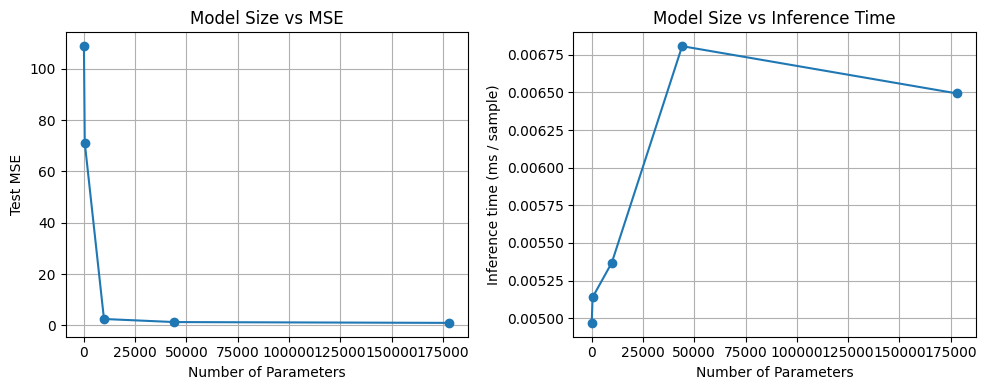

In [ ]:
import matplotlib.pyplot as plt

# MODEL SIZE = total number of params
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

param_counts = []
mses = []
times = []
names = []

for name, hdim in model_sizes.items():
    names.append(name)
    
    m = MLP(input_dim=input_dim, hidden_dims=hdim)
    param_counts.append(count_params(m))
    
    mses.append(results[name]["test_mse"])
    times.append(results[name]["time_per_sample_ms"])

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(param_counts, mses, "-o")
plt.xlabel("Number of Parameters")
plt.ylabel("Test MSE")
plt.title("Model Size vs MSE")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(param_counts, times, "-o")
plt.xlabel("Number of Parameters")
plt.ylabel("Inference time (ms / sample)")
plt.title("Model Size vs Inference Time")
plt.grid(True)
plt.tight_layout()
plt.show()


### Question 5 - Confidence-Based Cascade System

We evaluate how the small model’s predicted uncertainty $ \sigma_s(x) $ can be used as a 
routing decision in a two-stage cascade. Inputs with low predicted uncertainty are handled 
locally by the small model, while high-uncertainty inputs are forwarded to the large model.

---


#### Compute small model uncertainty on test set

In [29]:
@torch.no_grad()
def get_small_model_outputs(model, loader):
    sigmas = []
    mus = []
    ys = []

    for xb, yb in loader:
        mu, log_var = model(xb)
        sigma = torch.sqrt(torch.exp(log_var))

        mus.append(mu.cpu())
        sigmas.append(sigma.cpu())
        ys.append(yb.cpu())

    return torch.cat(mus), torch.cat(sigmas), torch.cat(ys)

small_mu, small_sigma, y_test_cpu = get_small_model_outputs(small_model, test_loader)


#### Cascade Evaluation Function

Given a threshold $T$, we compute the cascade prediction by  
accepting the small model when $\sigma_s(x) < T$ and otherwise  
routing the input to the large model.  
The function returns:
- the cascade MSE,
- the fraction of samples handled by the small model,
- the effective inference time  
  $t_{\text{eff}} = f_{\text{small}}\, t_{\text{small}} + (1 - f_{\text{small}})\, t_{\text{large}}$.


In [ ]:
@torch.no_grad()
def evaluate_cascade(T):
    total_preds = []
    count_small = 0
    total_time = 0.0

    # two loaders for convenience
    X_test_cpu = X_test.cpu()
    n = len(X_test_cpu)

    for i in range(n):
        sigma = small_sigma[i].item()

        if sigma < T:
            # accept small model
            pred = small_mu[i].item()
            count_small += 1
        else:
            # run large model on single sample
            x = X_test_cpu[i].unsqueeze(0).to(device)
            start = time.time()
            mu_l, _ = large_model(x)
            end = time.time()
            pred = mu_l.item()
            total_time += (end - start)

        total_preds.append(pred)

    preds = torch.tensor(total_preds)
    mse = torch.mean((preds - y_test_cpu)**2).item()

    # compute effective inference time
    small_time = results['small']['time_per_sample_ms'] / 1000
    frac_small = count_small / n

    effective_time = frac_small * small_time + total_time / n

    return mse, frac_small, effective_time


#### Sweep thresholds and collect results

In [32]:
thresholds = torch.linspace(0.1, 6.0, 25)
cascade_mse = []
cascade_frac_small = []
cascade_time = []

for T in thresholds:
    mse, frac_small, eff_time = evaluate_cascade(T.item())
    cascade_mse.append(mse)
    cascade_frac_small.append(frac_small)
    cascade_time.append(eff_time)


#### Cascade Behavior Plot

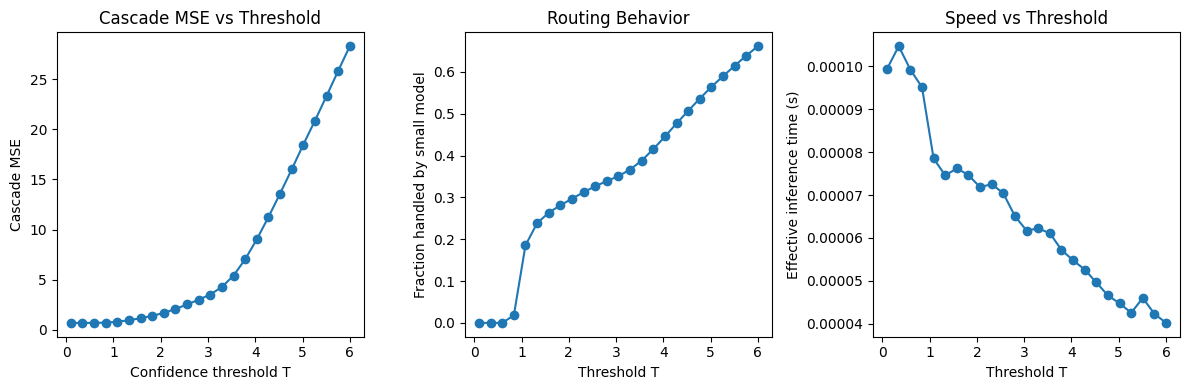

In [33]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(thresholds, cascade_mse, '-o')
plt.xlabel("Confidence threshold T")
plt.ylabel("Cascade MSE")
plt.title("Cascade MSE vs Threshold")

plt.subplot(1,3,2)
plt.plot(thresholds, cascade_frac_small, '-o')
plt.xlabel("Threshold T")
plt.ylabel("Fraction handled by small model")
plt.title("Routing Behavior")

plt.subplot(1,3,3)
plt.plot(thresholds, cascade_time, '-o')
plt.xlabel("Threshold T")
plt.ylabel("Effective inference time (s)")
plt.title("Speed vs Threshold")

plt.tight_layout()
plt.show()


### Question 6 - Effect of the Small-Model Loss Function on Cascade Performance

We train the small model using different regression losses (MSE, RMSE, MSLE, MAE, Huber)  
and study how each loss influences:
- the quality of the predicted error/uncertainty,
- the routing decisions in the cascade,
- and the resulting accuracy–latency trade-off.

A separate uncertainty predictor $\hat{e}(x)$ is learned from the small model’s hidden 
representation, allowing the cascade to use thresholds on $\hat{e}(x)$ instead of $\sigma_s(x)$

---


In [ ]:
import torch.nn.functional as F

# (Re)define losses in a dictionary for looping
loss_fns = {
    "MSE": lambda y, yhat: F.mse_loss(yhat, y),
    "RMSE": lambda y, yhat: torch.sqrt(F.mse_loss(yhat, y) + 1e-8),
    "MSLE": lambda y, yhat: F.mse_loss(torch.log1p(yhat.clamp(min=0)), torch.log1p(y.clamp(min=0))),
    "MAE": lambda y, yhat: F.l1_loss(yhat, y),
}

huber = nn.HuberLoss(delta=1.0)
loss_fns["Huber"] = lambda y, yhat: huber(yhat, y)


#### Small model architecture (without variance head)

A lightweight MLP that predicts only the mean $\mu(x)$ and returns its hidden 
representation $h(x)$ for learning a separate uncertainty model.


In [68]:
class SmallModel_NoVar(nn.Module):
    def __init__(self, input_dim, hidden_dim=32):
        super().__init__()
        self.hidden = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
        )
        self.mean_head = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        h = self.hidden(x)
        mu = self.mean_head(h).squeeze(-1)
        return mu, h


#### Train a model with given loss

In [69]:
def train_small_loss(model, loss_fn, loader, n_epochs=5, lr=1e-3):
    opt = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(1, n_epochs+1):
        model.train()
        running = 0.0
        count = 0

        for xb, yb in loader:
            opt.zero_grad()
            mu, _ = model(xb)
            loss = loss_fn(yb, mu)
            loss.backward()
            opt.step()

            running += loss.item() * xb.size(0)
            count += xb.size(0)

        print(f"[Epoch {epoch}] Loss={running/count:.4f}")

    return model


#### Learn a confidence model for σ(x)

In [ ]:
class UncertaintyModel(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Softplus()   # ensures σ >= 0
        )

    def forward(self, h):
        sigma = self.net(h).squeeze(-1)
        return sigma


#### Fit uncertainty model:

We learn an uncertainty predictor $\hat{e}(x)$ by fitting a small network to the 
absolute errors of the small model. The hidden representation $h(x)$ is used as input, 
and true errors are normalised to stabilise training. This model later provides the 
cascade’s confidence score.


In [ ]:
def fit_uncertainty_model(model, train_loader, val_loader):
    """
    Fit uncertainty model on VALIDATION data where we compute actual errors.
    This allows the model to learn what errors look like.
    """
    model.eval()
    H_train = []
    E_train = []
    
    # collect representations and errors from training data
    with torch.no_grad():
        for xb, yb in train_loader:
            mu, h = model(xb)
            err = torch.abs(mu - yb)
            H_train.append(h.cpu())
            E_train.append(err.cpu())
    
    H_train = torch.cat(H_train)
    E_train = torch.cat(E_train)
    
    # normalize errors to [0, 1] range for better training
    E_min, E_max = E_train.min(), E_train.max()
    E_train_norm = (E_train - E_min) / (E_max - E_min + 1e-8)
    
    print(f"Error statistics: min={E_min:.4f}, max={E_max:.4f}, mean={E_train.mean():.4f}")

    unc_model = UncertaintyModel(hidden_dim=H_train.shape[1]).to(device)
    opt = optim.Adam(unc_model.parameters(), lr=1e-3)

    dataset = TensorDataset(H_train.to(device), E_train_norm.to(device))
    dl = DataLoader(dataset, batch_size=4096, shuffle=True)

    # train for more epochs to better fit error magnitude
    for epoch in range(30):
        total_loss = 0.0
        for hb, eb in dl:
            opt.zero_grad()
            pred = unc_model(hb)
            # denormalize predictions to match actual error scale
            pred_denorm = pred * (E_max - E_min) + E_min
            loss = F.mse_loss(pred_denorm, eb * (E_max - E_min) + E_min)
            loss.backward()
            opt.step()
            total_loss += loss.item()
        if epoch % 10 == 0:
            print(f"  [Uncertainty Epoch {epoch}] Loss={total_loss/len(dl):.6f}")

    return unc_model, E_min, E_max


#### Evaluate cascade for each loss

For a given threshold $T$, the uncertainty model predicts the expected error  
$\hat{e}(x)$ for each input.  
If $\hat{e}(x) \le T$, the cascade accepts the small model’s prediction;  
otherwise, the input is routed to the large model.

The function returns:
- the cascade MSE,
- the fraction of samples handled by the small model.


In [ ]:
@torch.no_grad()
def evaluate_cascade_for_loss(
    T,
    small_model,
    unc_model,
    large_model,
    test_loader,
    device,
    err_min,
    err_max
):
    
    small_model.eval()
    unc_model.eval()
    large_model.eval()

    all_preds = []
    all_targets = []
    total_small = 0
    total_samples = 0

    for xb, yb in test_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        # step 1: small model + uncertainty
        mu_small, h = small_model(xb)
        pred_err_norm = unc_model(h)  # normalized [0, 1]
        pred_err = pred_err_norm * (err_max - err_min) + err_min  # denormalized

        # if predicted error <= T, use small model
        mask_small = pred_err <= T
        mask_large = ~mask_small

        preds_batch = torch.empty_like(mu_small)
        preds_batch[mask_small] = mu_small[mask_small]
        n_small_batch = mask_small.sum().item()

        # step 2: large model for uncertain samples
        if mask_large.any():
            xb_large = xb[mask_large]
            mu_large, _ = large_model(xb_large)
            preds_batch[mask_large] = mu_large

        all_preds.append(preds_batch.cpu())
        all_targets.append(yb.cpu())

        total_small += n_small_batch
        total_samples += xb.size(0)

    preds = torch.cat(all_preds)
    targets = torch.cat(all_targets)

    mse_cascade = F.mse_loss(preds, targets).item()
    frac_small = total_small / total_samples

    return mse_cascade, frac_small


#### Master loop over losses: train small model + uncertainty + cascade sweep

For each loss (MSE, RMSE, MSLE, MAE, Huber), we:
1. Train a small model using that loss.  
2. Fit an uncertainty model to predict its errors.  
3. Sweep thresholds $T$ to build a cascade and measure:
   - cascade MSE,
   - fraction of samples handled by the small model,
   - effective inference time.  
We store all curves and the best-performing threshold for later analysis.


In [ ]:
results_q6 = {}

for loss_name, loss_fn in loss_fns.items():
    print(f"\n==============================")
    print(f"   Loss: {loss_name}")
    print(f"==============================")

    # train small model with this loss
    small_model = SmallModel_NoVar(input_dim=input_dim, hidden_dim=32).to(device)
    print(f"Training small model with {loss_name} loss...")
    small_model = train_small_loss(
        small_model,
        loss_fn,
        train_subset_loader,
        n_epochs=5,
        lr=1e-3
    )

    # fit uncertainty model on training data to learn error prediction
    print("Fitting uncertainty model to predict errors...")
    unc_model, err_min, err_max = fit_uncertainty_model(small_model, train_subset_loader, val_loader)

    # measure inference times
    small_time_s, _ = measure_inference_time(small_model, X_test)
    large_time_s, _ = measure_inference_time(large_model, X_test)

    print(f"Small ({loss_name}) time per sample: {small_time_s*1000:.4f} ms")
    print(f"Large model time per sample:        {large_time_s*1000:.4f} ms")

    # sweep thresholds (in terms of predicted error, not sigma)
    thresholds = torch.linspace(err_min.item(), err_max.item() * 0.5, 41)
    mse_list = []
    frac_small_list = []
    time_list = []

    for T in thresholds:
        T_val = T.item()
        mse_casc, frac_small = evaluate_cascade_for_loss(
            T_val,
            small_model,
            unc_model,
            large_model,
            test_loader,
            device,
            err_min,
            err_max
        )
        mse_list.append(mse_casc)
        frac_small_list.append(frac_small)
        eff_time = frac_small * small_time_s + (1 - frac_small) * large_time_s
        time_list.append(eff_time)

    mse_arr = np.array(mse_list)
    frac_arr = np.array(frac_small_list)
    time_arr = np.array(time_list)
    T_arr = thresholds.numpy()

    # select best threshold
    best_idx = np.argmin(mse_arr)
    best_T = T_arr[best_idx]
    best_mse = mse_arr[best_idx]
    best_frac = frac_arr[best_idx]
    best_time = time_arr[best_idx]

    print(f"\nBest for {loss_name}:")
    print(f"  T* = {best_T:.4f}")
    print(f"  Cascade MSE = {best_mse:.4f}")
    print(f"  Fraction handled by small model = {best_frac:.4f}")
    print(f"  Effective time per sample = {best_time*1000:.4f} ms")

    results_q6[loss_name] = {
        "best_T": best_T,
        "cascade_mse": best_mse,
        "frac_small": best_frac,
        "time_per_sample_ms": best_time * 1000,
        "small_time_ms": small_time_s * 1000,
        "large_time_ms": large_time_s * 1000,
    }

    results_q6[loss_name]["thresholds"] = T_arr
    results_q6[loss_name]["mse_curve"] = mse_arr
    results_q6[loss_name]["frac_curve"] = frac_arr
    results_q6[loss_name]["time_curve"] = time_arr



   Loss: MSE
Training small model with MSE loss...
[Epoch 1] Loss=102.4616
[Epoch 1] Loss=102.4616
[Epoch 2] Loss=81.4744
[Epoch 2] Loss=81.4744
[Epoch 3] Loss=53.9070
[Epoch 3] Loss=53.9070
[Epoch 4] Loss=27.0522
[Epoch 4] Loss=27.0522
[Epoch 5] Loss=10.9500
Fitting uncertainty model to predict errors...
[Epoch 5] Loss=10.9500
Fitting uncertainty model to predict errors...
Error statistics: min=0.0000, max=18.3400, mean=2.2183
Error statistics: min=0.0000, max=18.3400, mean=2.2183
  [Uncertainty Epoch 0] Loss=15.338701
  [Uncertainty Epoch 0] Loss=15.338701
  [Uncertainty Epoch 10] Loss=0.984271
  [Uncertainty Epoch 10] Loss=0.984271
  [Uncertainty Epoch 20] Loss=0.654496
  [Uncertainty Epoch 20] Loss=0.654496
Small (MSE) time per sample: 0.0050 ms
Large model time per sample:        0.0057 ms
Small (MSE) time per sample: 0.0050 ms
Large model time per sample:        0.0057 ms

Best for MSE:
  T* = 0.0000
  Cascade MSE = 0.6983
  Fraction handled by small model = 0.0000
  Effective t

#### Selecting a Balanced Operating Point (≈25% Small-Model Usage)

Instead of choosing the threshold $T$ that minimises MSE (which routes almost everything 
to the large model), we pick the threshold that yields a target routing fraction 
(e.g., 25%).  
For each loss, we extract:

- the threshold closest to the desired fraction,
- the resulting cascade MSE,
- the actual fraction handled by the small model,
- the effective latency.

This provides a fair comparison of all loss functions under similar computational budgets

In [ ]:
target_frac = 0.25

balanced_rows = []

for loss_name, vals in results_q6.items():
    T_arr = vals["thresholds"]
    frac_arr = vals["frac_curve"]
    mse_arr = vals["mse_curve"]
    time_arr = vals["time_curve"]

    # index whose frac_small is closest to target_frac
    idx = np.argmin(np.abs(frac_arr - target_frac))

    T_bal   = T_arr[idx]
    frac_bal = frac_arr[idx]
    mse_bal  = mse_arr[idx]
    time_bal = time_arr[idx] * 1000  # ms/sample

    balanced_rows.append({
        "Loss": loss_name,
        "T_balanced": T_bal,
        "Frac_small": frac_bal,
        "Cascade_MSE": mse_bal,
        "Eff_time_ms": time_bal,
    })

df_balanced = pd.DataFrame(balanced_rows).set_index("Loss")
df_balanced


,T_balanced,Frac_small,Cascade_MSE,Eff_time_ms
Loss,,,,
MSE,1.375530,0.281864,0.878392,0.005497
RMSE,1.094051,0.311349,1.030510,0.005435
MSLE,4.415315,0.240373,3.587712,0.006099
MAE,0.966538,0.257904,0.802153,0.005521
Huber,0.919339,0.312163,0.778644,0.005803


#### Curves: MSE and Fraction vs Threshold (one figure per loss)

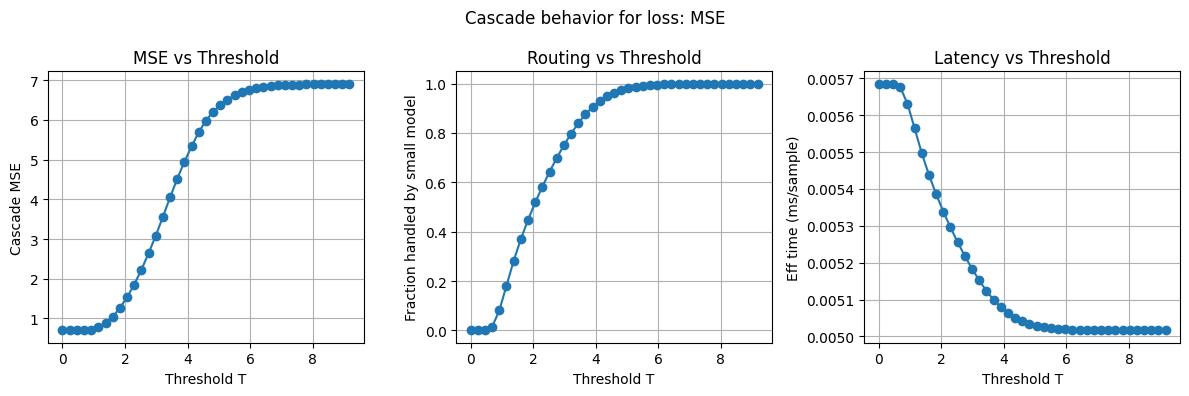

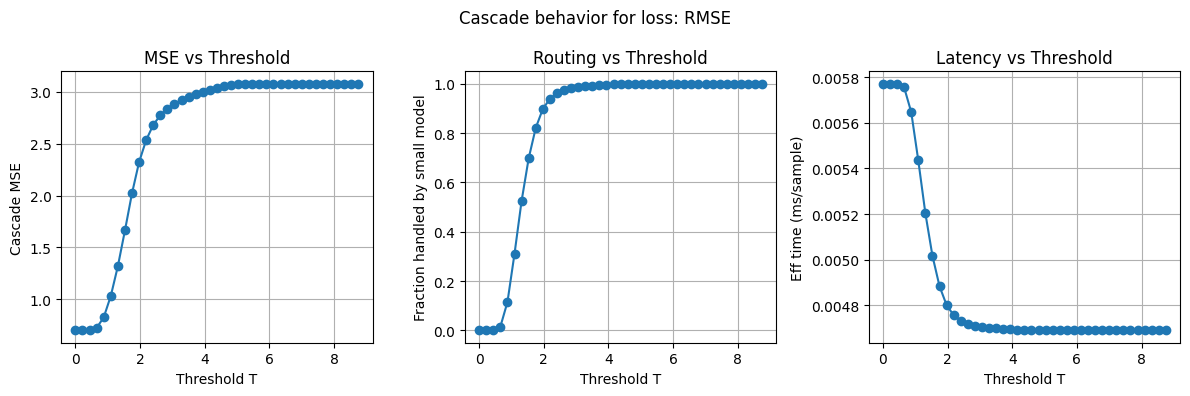

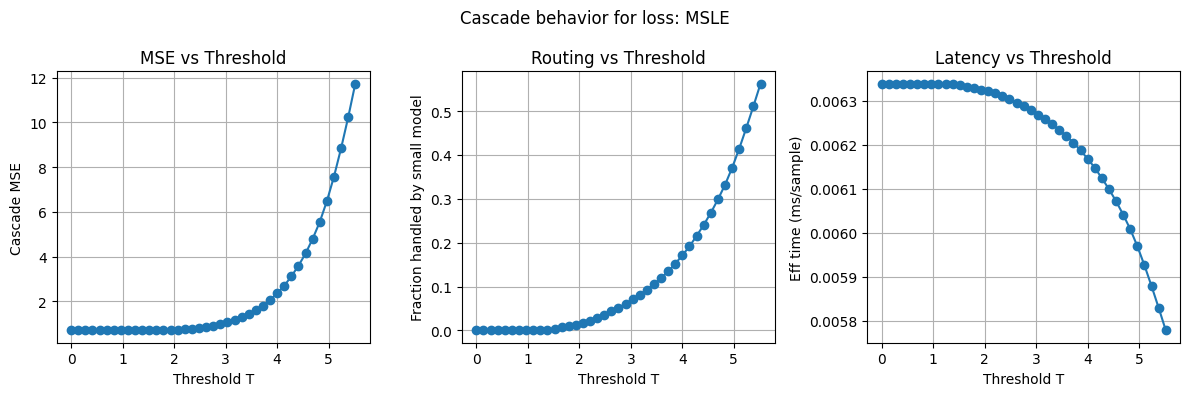

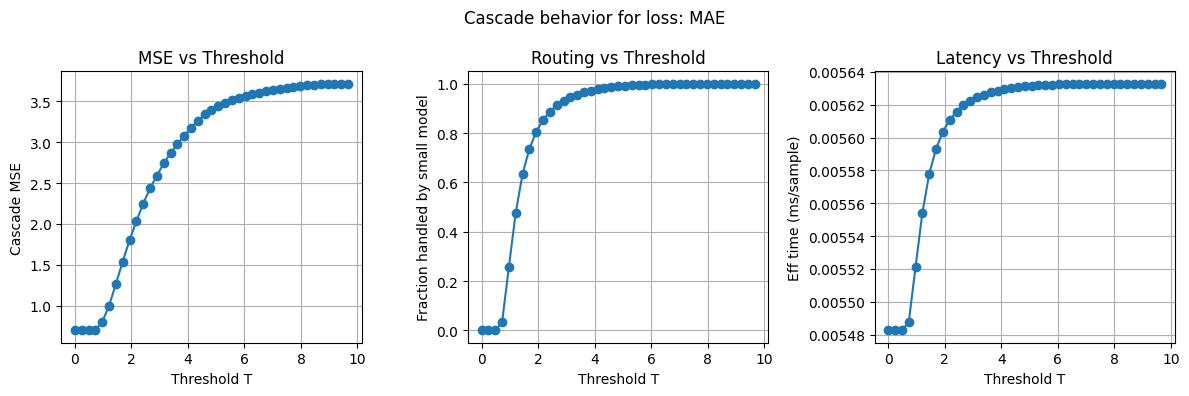

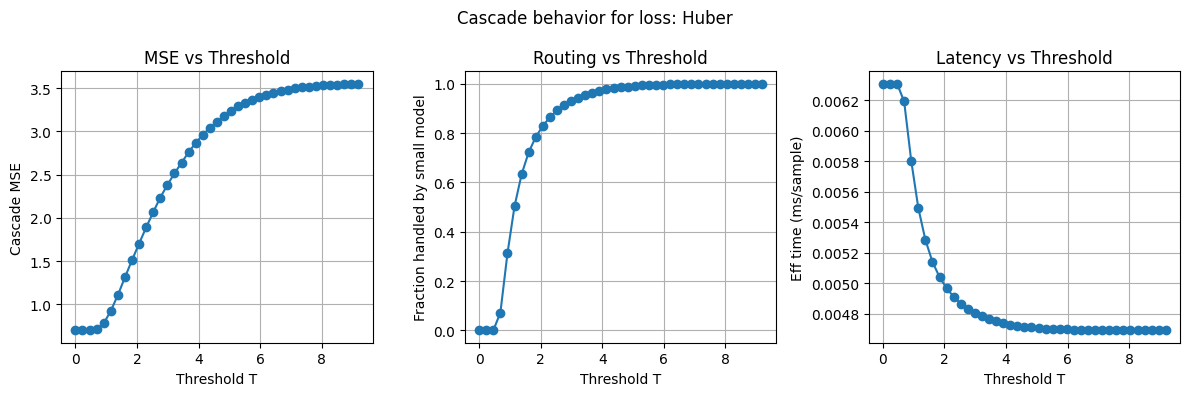

In [75]:
import matplotlib.pyplot as plt

for loss_name, vals in results_q6.items():
    T_arr = vals["thresholds"]
    mse_arr = vals["mse_curve"]
    frac_arr = vals["frac_curve"]
    time_arr = vals["time_curve"]

    plt.figure(figsize=(12,4))
    plt.suptitle(f"Cascade behavior for loss: {loss_name}")

    # MSE vs T
    plt.subplot(1,3,1)
    plt.plot(T_arr, mse_arr, "-o")
    plt.xlabel("Threshold T")
    plt.ylabel("Cascade MSE")
    plt.title("MSE vs Threshold")
    plt.grid(True)

    # Fraction small vs T
    plt.subplot(1,3,2)
    plt.plot(T_arr, frac_arr, "-o")
    plt.xlabel("Threshold T")
    plt.ylabel("Fraction handled by small model")
    plt.title("Routing vs Threshold")
    plt.grid(True)

    # Time vs T
    plt.subplot(1,3,3)
    plt.plot(T_arr, time_arr*1000, "-o")
    plt.xlabel("Threshold T")
    plt.ylabel("Eff time (ms/sample)")
    plt.title("Latency vs Threshold")
    plt.grid(True)

    plt.tight_layout()
    plt.show()


#### Bar plots: best cascade MSE and fraction-small by loss

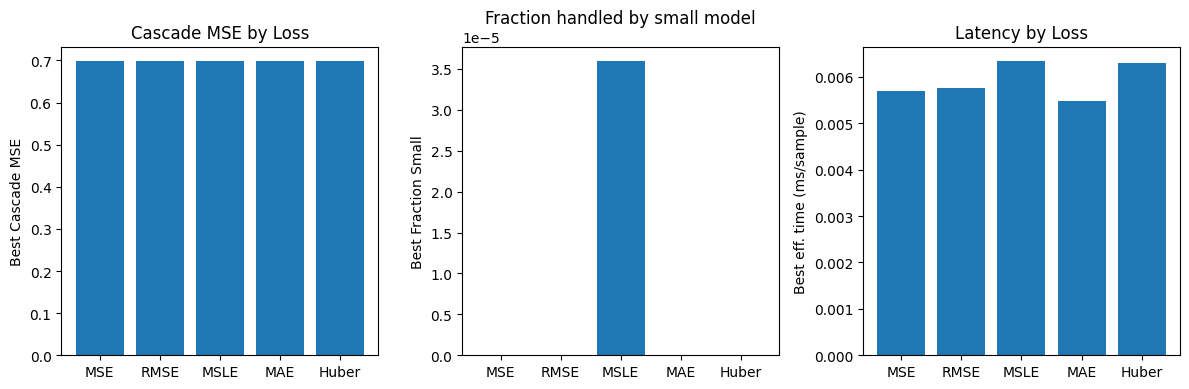

In [76]:
loss_names = list(results_q6.keys())
best_mses = [results_q6[ln]["cascade_mse"] for ln in loss_names]
best_fracs = [results_q6[ln]["frac_small"] for ln in loss_names]
best_times = [results_q6[ln]["time_per_sample_ms"] for ln in loss_names]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.bar(loss_names, best_mses)
plt.ylabel("Best Cascade MSE")
plt.title("Cascade MSE by Loss")

plt.subplot(1,3,2)
plt.bar(loss_names, best_fracs)
plt.ylabel("Best Fraction Small")
plt.title("Fraction handled by small model")

plt.subplot(1,3,3)
plt.bar(loss_names, best_times)
plt.ylabel("Best eff. time (ms/sample)")
plt.title("Latency by Loss")

plt.tight_layout()
plt.show()


### Question 7 - Another Regression Task & Dataset (California Housing)

In this question, we test whether the confidence–based cascade generalises beyond the  
ACS Income task.  
We use the **California Housing** dataset to predict median house values from  
8 numerical features.

We:

- load and standardise the features,
- apply a log-transform to the target  
  $y = \log(1 + y_{\text{raw}})$,
- train a **small** and a **large** heteroscedastic MLP that output  
  $\mu(x)$ and $\log \sigma^2(x)$,
- build a two-stage cascade using the small-model uncertainty  
  $\sigma_s(x)$ as the routing signal.

By sweeping the threshold $T$, we analyse how the cascade trades off  
test MSE versus latency on this second regression task.


##### Load and prepare California Housing

In [ ]:
from sklearn.datasets import fetch_california_housing
import math

# load dataset (median house value prediction)
cal = fetch_california_housing()
X = cal.data.astype(np.float32)
y = cal.target.astype(np.float32)  # in 100k$

# log-transform target to reduce skewness
y = np.log1p(y)

# train/val/test split
X_train_full, X_test_c, y_train_full, y_test_c = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train_c, X_val_c, y_train_c, y_val_c = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

# standardize features
scaler = StandardScaler()
X_train_c = scaler.fit_transform(X_train_c)
X_val_c   = scaler.transform(X_val_c)
X_test_c  = scaler.transform(X_test_c)

# to tensors / loaders
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_ct = torch.tensor(X_train_c, device=device)
y_train_ct = torch.tensor(y_train_c, device=device)
X_val_ct   = torch.tensor(X_val_c, device=device)
y_val_ct   = torch.tensor(y_val_c, device=device)
X_test_ct  = torch.tensor(X_test_c, device=device)
y_test_ct  = torch.tensor(y_test_c, device=device)

train_c_loader = DataLoader(TensorDataset(X_train_ct, y_train_ct), batch_size=2048, shuffle=True)
val_c_loader   = DataLoader(TensorDataset(X_val_ct, y_val_ct), batch_size=4096, shuffle=False)
test_c_loader  = DataLoader(TensorDataset(X_test_ct, y_test_ct), batch_size=4096, shuffle=False)

input_dim_c = X_train_ct.shape[1]
print("California Housing input_dim:", input_dim_c)


California Housing input_dim: 8


##### Heteroscedastic models + training loop

We define a heteroscedastic MLP that outputs both the mean $ \mu(x) $  
and the log-variance $ \log \sigma^2(x) $.  
The model is trained using the **Gaussian Negative Log-Likelihood** loss:

$$
\mathcal{L}_{\text{NLL}}
= \frac{1}{2} \left(
\log \sigma^2(x) +
\frac{(y - \mu(x))^2}{\sigma^2(x)} +
\log 2\pi
\right).
$$

This objective encourages the network to predict:

- small variance $ \sigma(x) $ on easy, low-noise samples,
- large variance on difficult or noisy samples.

For evaluation, we compute:

- the test MSE using only the predicted mean $ \mu(x) $,  
- and the average predicted standard deviation $ \sigma(x) $ over the dataset.


In [79]:
def gaussian_nll_loss(mu, log_var, y):
    var = torch.exp(log_var) + 1e-6
    return 0.5 * ((y - mu)**2 / var + log_var + math.log(2*math.pi)).mean()

class HeteroMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            prev = h
        self.backbone = nn.Sequential(*layers)
        self.mean_head = nn.Linear(prev, 1)
        self.log_var_head = nn.Linear(prev, 1)

    def forward(self, x):
        h = self.backbone(x)
        mu = self.mean_head(h).squeeze(-1)
        log_var = self.log_var_head(h).squeeze(-1)
        return mu, log_var

def train_gauss_model(model, train_loader, val_loader, n_epochs=20, lr=1e-3):
    model = model.to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    for epoch in range(1, n_epochs+1):
        model.train()
        total, n = 0.0, 0
        for xb, yb in train_loader:
            opt.zero_grad()
            mu, log_var = model(xb)
            loss = gaussian_nll_loss(mu, log_var, yb)
            loss.backward()
            opt.step()
            total += loss.item() * xb.size(0)
            n += xb.size(0)
        if epoch % 5 == 0 or epoch == 1:
            # quick val NLL
            model.eval()
            with torch.no_grad():
                vsum, vn = 0.0, 0
                for xb, yb in val_loader:
                    mu, log_var = model(xb)
                    vloss = gaussian_nll_loss(mu, log_var, yb)
                    vsum += vloss.item() * xb.size(0)
                    vn += xb.size(0)
            print(f"[Epoch {epoch:3d}] Train NLL={total/n:.4f} | Val NLL={vsum/vn:.4f}")
    return model

@torch.no_grad()
def eval_mse_sigma(model, loader):
    model.eval()
    preds, targets, sigmas = [], [], []
    for xb, yb in loader:
        mu, log_var = model(xb)
        preds.append(mu.cpu())
        targets.append(yb.cpu())
        sigmas.append(torch.sqrt(torch.exp(log_var)).cpu())
    preds = torch.cat(preds)
    targets = torch.cat(targets)
    sigmas = torch.cat(sigmas)
    mse = torch.mean((preds - targets)**2).item()
    return mse, sigmas.mean().item()


#### Train small & large models + cascade

We train two heteroscedastic networks on the standardized California Housing dataset:

- a **small model** with one hidden layer of size $32$,  
- a **large model** with hidden layers $(256,\,128,\,64)$.

Both models output $ \mu(x) $ and $ \log \sigma^2(x) $ and are trained for 15 epochs using the Gaussian NLL loss.  
After training, we evaluate each model on the test set, reporting:

- the test mean squared error (MSE),  
- the average predicted uncertainty $ \sigma(x) $.

This comparison mirrors Question 3 but on a new regression task, allowing us to assess how model capacity and heteroscedastic confidence generalize across datasets.


In [ ]:
# small model
small_c = HeteroMLP(input_dim_c, hidden_dims=[32])
print("Training SMALL heteroscedastic model on California...")
small_c = train_gauss_model(small_c, train_c_loader, val_c_loader, n_epochs=15, lr=1e-3)
small_mse, small_sigma = eval_mse_sigma(small_c, test_c_loader)
print(f"[California SMALL] Test MSE={small_mse:.4f}, mean sigma={small_sigma:.4f}")

# large model
large_c = HeteroMLP(input_dim_c, hidden_dims=[256, 128, 64])
print("\nTraining LARGE heteroscedastic model on California...")
large_c = train_gauss_model(large_c, train_c_loader, val_c_loader, n_epochs=15, lr=1e-3)
large_mse, large_sigma = eval_mse_sigma(large_c, test_c_loader)
print(f"[California LARGE] Test MSE={large_mse:.4f}, mean sigma={large_sigma:.4f}")


Training SMALL heteroscedastic model on California...
[Epoch   1] Train NLL=1.9696 | Val NLL=1.8941
[Epoch   5] Train NLL=1.5728 | Val NLL=1.5411
[Epoch   5] Train NLL=1.5728 | Val NLL=1.5411
[Epoch  10] Train NLL=1.3017 | Val NLL=1.2771
[Epoch  10] Train NLL=1.3017 | Val NLL=1.2771
[Epoch  15] Train NLL=1.0303 | Val NLL=1.0614
[California SMALL] Test MSE=0.3412, mean sigma=0.8950

Training LARGE heteroscedastic model on California...
[Epoch  15] Train NLL=1.0303 | Val NLL=1.0614
[California SMALL] Test MSE=0.3412, mean sigma=0.8950

Training LARGE heteroscedastic model on California...
[Epoch   1] Train NLL=1.2911 | Val NLL=1.1405
[Epoch   1] Train NLL=1.2911 | Val NLL=1.1405
[Epoch   5] Train NLL=0.4756 | Val NLL=0.3721
[Epoch   5] Train NLL=0.4756 | Val NLL=0.3721
[Epoch  10] Train NLL=-0.1436 | Val NLL=-0.1149
[Epoch  10] Train NLL=-0.1436 | Val NLL=-0.1149
[Epoch  15] Train NLL=-0.2983 | Val NLL=-0.2594
[California LARGE] Test MSE=0.0350, mean sigma=0.1826
[Epoch  15] Train NLL=-0

#### Cascade evaluation + plots (California)

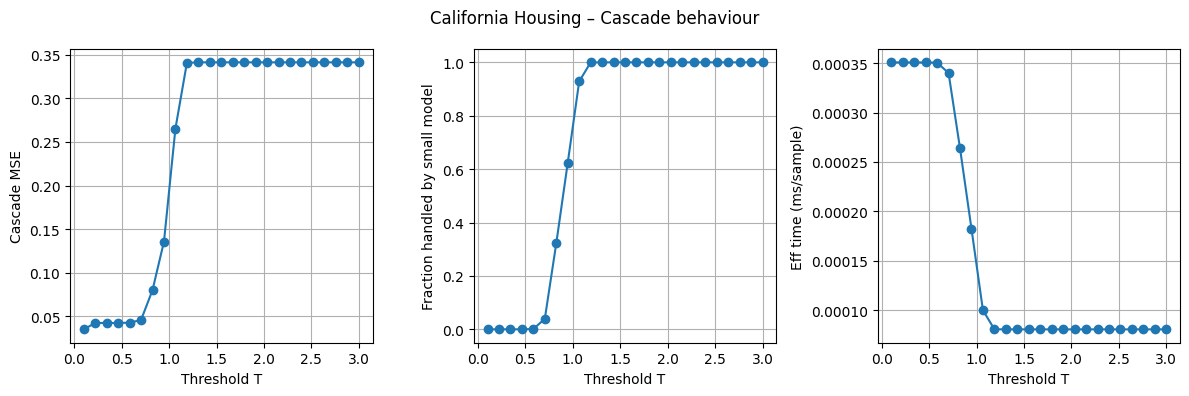

In [81]:
@torch.no_grad()
def eval_cascade_gauss(T, small_model, large_model, loader):
    small_model.eval(); large_model.eval()
    preds, targets = [], []
    total_small, total = 0, 0
    for xb, yb in loader:
        mu_s, log_var_s = small_model(xb)
        sigma_s = torch.sqrt(torch.exp(log_var_s))
        mask_small = sigma_s <= T
        mask_large = ~mask_small

        batch_pred = torch.empty_like(mu_s)
        batch_pred[mask_small] = mu_s[mask_small]

        if mask_large.any():
            xb_large = xb[mask_large]
            mu_l, _ = large_model(xb_large)
            batch_pred[mask_large] = mu_l

        preds.append(batch_pred.cpu())
        targets.append(yb.cpu())
        total_small += mask_small.sum().item()
        total += xb.size(0)

    preds = torch.cat(preds); targets = torch.cat(targets)
    mse = torch.mean((preds - targets)**2).item()
    frac_small = total_small / total
    return mse, frac_small

def measure_inference_time(model, X_tensor, n_runs=3):
    model.eval()
    with torch.no_grad():
        # warmup
        _ = model(X_tensor[:1024])
        start = time.time()
        for _ in range(n_runs):
            _ = model(X_tensor)
        end = time.time()
    total_s = (end - start) / n_runs
    return total_s / X_tensor.size(0)

# sweep thresholds
import time
Ts = torch.linspace(0.1, 3.0, 25)
mse_list, frac_list, time_list = [], [], []

small_time_c = measure_inference_time(small_c, X_test_ct)
large_time_c = measure_inference_time(large_c, X_test_ct)

for T in Ts:
    T_val = T.item()
    mse_casc, frac_small = eval_cascade_gauss(T_val, small_c, large_c, test_c_loader)
    mse_list.append(mse_casc)
    frac_list.append(frac_small)
    eff_t = frac_small * small_time_c + (1 - frac_small) * large_time_c
    time_list.append(eff_t)

Ts_np = Ts.cpu().numpy()
mse_np = np.array(mse_list)
frac_np = np.array(frac_list)
time_np = np.array(time_list)

plt.figure(figsize=(12,4))
plt.suptitle("California Housing – Cascade behaviour")

plt.subplot(1,3,1)
plt.plot(Ts_np, mse_np, "-o")
plt.xlabel("Threshold T")
plt.ylabel("Cascade MSE")
plt.grid(True)

plt.subplot(1,3,2)
plt.plot(Ts_np, frac_np, "-o")
plt.xlabel("Threshold T")
plt.ylabel("Fraction handled by small model")
plt.grid(True)

plt.subplot(1,3,3)
plt.plot(Ts_np, time_np*1000, "-o")
plt.xlabel("Threshold T")
plt.ylabel("Eff time (ms/sample)")
plt.grid(True)

plt.tight_layout()
plt.show()


### Question 8: New Training Procedure - Large Model Trained Only on Hard Samples

In this experiment, we investigate whether the large model can be improved by  
**specializing** it on the most difficult inputs-those on which the small model performs poorly.

We first train the small model and compute its absolute prediction errors  
$ e(x) = |y - \mu_s(x)| $.  
Samples whose errors lie above the $70^{\text{th}}$ percentile form the **hard subset**  
$ \mathcal{D}_{\text{hard}} $, representing approximately 30% of the training data.

We then train two large models:

- a **baseline large model** trained on the full dataset $ \mathcal{D}_{\text{train}} $,  
- a **specialized large model** trained only on the hard subset $ \mathcal{D}_{\text{hard}} $.  

Both models are incorporated into the same uncertainty-based cascade described earlier.  
We compare the two resulting cascades in terms of:

- cascade MSE as a function of the threshold \( T \),  
- the fraction of samples routed to the small model,  
- and the effective latency per sample combining both stages.

This unified evaluation reveals whether specialization improves the cascade's accuracy-latency trade-off,  
or whether training on the full distribution remains superior for overall generalization.

---


Using device: cpu
ACS input_dim: 10
Train / Val / Test shapes: torch.Size([1335218, 10]) torch.Size([166902, 10]) torch.Size([166903, 10])

Training SMALL model on full ACS data...
[Epoch   1] Train NLL=16.4650 | Val NLL=4.2996
[Epoch   5] Train NLL=2.5458 | Val NLL=2.2933
[Epoch  10] Train NLL=1.3619 | Val NLL=1.3397
[Epoch  15] Train NLL=1.2283 | Val NLL=1.2272
[SMALL model] Test MSE (full data) = 0.7675

Training BASELINE LARGE model on full ACS data...
[Epoch   1] Train NLL=3.6366 | Val NLL=1.2528
[Epoch   5] Train NLL=1.1581 | Val NLL=1.1652
[Epoch  10] Train NLL=1.1375 | Val NLL=1.1456
[Epoch  15] Train NLL=1.1251 | Val NLL=1.1401
[LARGE baseline] Test MSE (full data) = 0.7019

Computing small-model errors on training set...
Error threshold for hard samples (70th percentile): 0.6986
Fraction of hard samples: 0.3000
Hard train tensor shape: torch.Size([400566, 10])

Training SPECIALIZED LARGE model on hard ACS samples only...
[Epoch   1] Train NLL=7.1913 | Val NLL=3.4462
[Epoch   

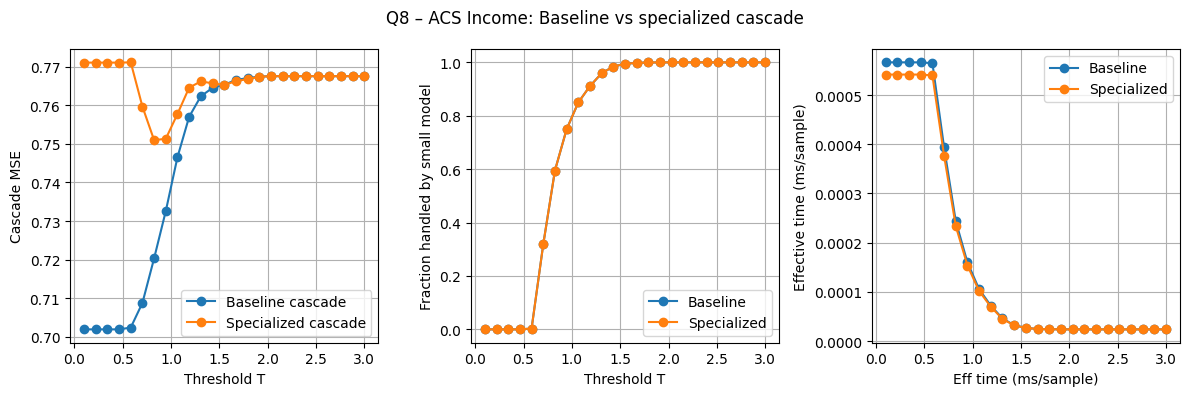

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# reconstruct full train / val / test tensors from loaders
def loader_to_tensors(loader, device=device):
    X_list, y_list = [], []
    # NOTE: we will infer dims from the first batch
    for i, (xb, yb) in enumerate(loader):
        if i == 0:
            X_list = [xb]
            y_list = [yb]
        else:
            X_list.append(xb)
            y_list.append(yb)
    X = torch.cat(X_list).to(device)
    y = torch.cat(y_list).to(device)
    return X, y

X_train_all, y_train_all = loader_to_tensors(train_loader, device)
X_val_all,   y_val_all   = loader_to_tensors(val_loader, device)
X_test_all,  y_test_all  = loader_to_tensors(test_loader, device)

input_dim = X_train_all.shape[1]
print("ACS input_dim:", input_dim)
print("Train / Val / Test shapes:",
      X_train_all.shape, X_val_all.shape, X_test_all.shape)



# Heteroscedastic Gaussian NLL model + training / eval
def gaussian_nll_loss(mu, log_var, y):
    var = torch.exp(log_var) + 1e-6
    return 0.5 * ((y - mu)**2 / var + log_var + math.log(2 * math.pi)).mean()

class HeteroMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            prev = h
        self.backbone = nn.Sequential(*layers)
        self.mean_head = nn.Linear(prev, 1)
        self.log_var_head = nn.Linear(prev, 1)

    def forward(self, x):
        h = self.backbone(x)
        mu = self.mean_head(h).squeeze(-1)
        log_var = self.log_var_head(h).squeeze(-1)
        return mu, log_var

def train_gauss_model(model, train_loader, val_loader, n_epochs=15, lr=1e-3):
    model = model.to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    for epoch in range(1, n_epochs + 1):
        model.train()
        total, n = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            mu, log_var = model(xb)
            loss = gaussian_nll_loss(mu, log_var, yb)
            loss.backward()
            opt.step()
            total += loss.item() * xb.size(0)
            n += xb.size(0)

        if epoch == 1 or epoch % 5 == 0:
            # quick validation NLL
            model.eval()
            with torch.no_grad():
                v_total, v_n = 0.0, 0
                for xb, yb in val_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    mu, log_var = model(xb)
                    v_loss = gaussian_nll_loss(mu, log_var, yb)
                    v_total += v_loss.item() * xb.size(0)
                    v_n += xb.size(0)
            print(f"[Epoch {epoch:3d}] Train NLL={total/n:.4f} | Val NLL={v_total/v_n:.4f}")
    return model

@torch.no_grad()
def eval_mse(model, X, y):
    model.eval()
    mu, log_var = model(X.to(device))
    mse = torch.mean((mu - y.to(device))**2).item()
    return mse

@torch.no_grad()
def compute_abs_errors(model, X, y):
    model.eval()
    mu, log_var = model(X.to(device))
    err = torch.abs(mu - y.to(device))
    return err.cpu().numpy()



# train small and baseline large models on full ACS data

print("\nTraining SMALL model on full ACS data...")
small_model = HeteroMLP(input_dim, hidden_dims=[32])
small_train_loader = DataLoader(
    TensorDataset(X_train_all, y_train_all),
    batch_size=4096,
    shuffle=True
)
val_full_loader = DataLoader(
    TensorDataset(X_val_all, y_val_all),
    batch_size=4096,
    shuffle=False
)
small_model = train_gauss_model(small_model, small_train_loader, val_full_loader,
                                n_epochs=15, lr=1e-3)
small_mse_test = eval_mse(small_model, X_test_all, y_test_all)
print(f"[SMALL model] Test MSE (full data) = {small_mse_test:.4f}\n")

print("Training BASELINE LARGE model on full ACS data...")
large_model = HeteroMLP(input_dim, hidden_dims=[256, 128, 64])
large_train_loader = DataLoader(
    TensorDataset(X_train_all, y_train_all),
    batch_size=4096,
    shuffle=True
)
large_model = train_gauss_model(large_model, large_train_loader, val_full_loader,
                                n_epochs=15, lr=1e-3)
large_mse_test = eval_mse(large_model, X_test_all, y_test_all)
print(f"[LARGE baseline] Test MSE (full data) = {large_mse_test:.4f}\n")


# build HARD subset based on small-model errors

print("Computing small-model errors on training set...")
errors = compute_abs_errors(small_model, X_train_all, y_train_all)
q = 0.7        # top 30% hardest samples
thr_err = np.quantile(errors, q)
hard_mask = errors >= thr_err

print(f"Error threshold for hard samples (70th percentile): {thr_err:.4f}")
print(f"Fraction of hard samples: {hard_mask.mean():.4f}")

X_train_hard = X_train_all[hard_mask]
y_train_hard = y_train_all[hard_mask]

hard_train_loader = DataLoader(
    TensorDataset(X_train_hard, y_train_hard),
    batch_size=4096,
    shuffle=True
)
print("Hard train tensor shape:", X_train_hard.shape)



# train specialized large model on HARD samples only

print("\nTraining SPECIALIZED LARGE model on hard ACS samples only...")
large_hard_model = HeteroMLP(input_dim, hidden_dims=[256, 128, 64])
large_hard_model = train_gauss_model(
    large_hard_model,
    hard_train_loader,
    val_full_loader,    # validation still on full val set
    n_epochs=15,
    lr=1e-3
)

baseline_large_mse = eval_mse(large_model, X_test_all, y_test_all)
hard_large_mse     = eval_mse(large_hard_model, X_test_all, y_test_all)
print(f"\n[Baseline large] Test MSE (full-data training)   = {baseline_large_mse:.4f}")
print(f"[Hard-only large] Test MSE (hard-data training) = {hard_large_mse:.4f}\n")



# cascade evaluation: baseline vs specialized

@torch.no_grad()
def eval_cascade_gauss(T, small_model, large_model, X, y, batch_size=4096):
    small_model.eval(); large_model.eval()
    ds = TensorDataset(X, y)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)

    preds_list, targets_list = [], []
    total_small, total = 0, 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        mu_s, log_var_s = small_model(xb)
        sigma_s = torch.sqrt(torch.exp(log_var_s))

        mask_small = sigma_s <= T
        mask_large = ~mask_small

        batch_pred = torch.empty_like(mu_s)
        batch_pred[mask_small] = mu_s[mask_small]

        if mask_large.any():
            xb_large = xb[mask_large]
            mu_l, _ = large_model(xb_large)
            batch_pred[mask_large] = mu_l

        preds_list.append(batch_pred.cpu())
        targets_list.append(yb.cpu())

        total_small += mask_small.sum().item()
        total += xb.size(0)

    preds = torch.cat(preds_list)
    targets = torch.cat(targets_list)
    mse = torch.mean((preds - targets)**2).item()
    frac_small = total_small / total
    return mse, frac_small

def measure_inference_time(model, X, n_runs=3):
    model.eval()
    with torch.no_grad():
        _ = model(X[:1024])
        start = time.time()
        for _ in range(n_runs):
            _ = model(X)
        end = time.time()
    total_s = (end - start) / n_runs
    return total_s / X.size(0)


# measure per-sample times on test set
small_time = measure_inference_time(small_model, X_test_all)
large_time = measure_inference_time(large_model, X_test_all)
large_hard_time = measure_inference_time(large_hard_model, X_test_all)

print(f"Per-sample times (ms): small={small_time*1000:.4f}, "
      f"large={large_time*1000:.4f}, large_hard={large_hard_time*1000:.4f}")


# sweep thresholds T
Ts = torch.linspace(0.1, 3.0, 25)
mse_base, frac_base, time_base = [], [], []
mse_spec, frac_spec, time_spec = [], [], []

for T in Ts:
    T_val = T.item()

    # baseline cascade: small + large (full-data)
    mse_b, frac_b = eval_cascade_gauss(T_val, small_model, large_model,
                                       X_test_all, y_test_all)
    eff_b = frac_b * small_time + (1 - frac_b) * large_time
    mse_base.append(mse_b)
    frac_base.append(frac_b)
    time_base.append(eff_b)

    # specialized cascade: small + large_hard (hard-data)
    mse_s, frac_s = eval_cascade_gauss(T_val, small_model, large_hard_model,
                                       X_test_all, y_test_all)
    eff_s = frac_s * small_time + (1 - frac_s) * large_hard_time
    mse_spec.append(mse_s)
    frac_spec.append(frac_s)
    time_spec.append(eff_s)

Ts_np = Ts.cpu().numpy()
mse_base = np.array(mse_base)
mse_spec = np.array(mse_spec)
frac_base = np.array(frac_base)
frac_spec = np.array(frac_spec)
time_base = np.array(time_base)
time_spec = np.array(time_spec)


# plots: baseline vs specialized cascade

plt.figure(figsize=(12, 4))
plt.suptitle("Q8 – ACS Income: Baseline vs specialized cascade")

plt.subplot(1, 3, 1)
plt.plot(Ts_np, mse_base, "-o", label="Baseline cascade")
plt.plot(Ts_np, mse_spec, "-o", label="Specialized cascade")
plt.xlabel("Threshold T")
plt.ylabel("Cascade MSE")
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(Ts_np, frac_base, "-o", label="Baseline")
plt.plot(Ts_np, frac_spec, "-o", label="Specialized")
plt.xlabel("Threshold T")
plt.ylabel("Fraction handled by small model")
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(Ts_np, time_base * 1000, "-o", label="Baseline")
plt.plot(Ts_np, time_spec * 1000, "-o", label="Specialized")
plt.xlabel("Eff time (ms/sample)")
plt.ylabel("Effective time (ms/sample)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()





## Conclusion

In this notebook, we implemented and analysed confidence-based cascade models for
regression in an edge-computing context, using both real census data (ACS Income 2018)
and the California Housing dataset.

We first trained two probabilistic models on the ACS Income task: a small linear model
and a large heteroscedastic MLP with hidden sizes (256, 128, 64). Both models produced
a mean prediction and an input-dependent variance via the Gaussian NLL loss. As expected,
the large MLP achieved a much lower test MSE and a lower average predicted sigma, while
the linear model remained highly uncertain and inaccurate. This clearly positioned the
linear model as a fast but weak first stage, and the MLP as a slower but accurate
second stage in the cascade.

We then used the small model’s uncertainty estimates to build a confidence-based cascade:
for each input, the prediction from the small model was accepted when its predicted
standard deviation was below a threshold \(T\), and otherwise the input was forwarded to
the large model. By sweeping \(T\), we observed the characteristic trade-off between
accuracy and efficiency: small thresholds reproduced the performance of the large model
at full cost, large thresholds behaved like the small model with degraded accuracy, and
intermediate thresholds offered attractive compromises, offloading a significant fraction
of samples to the small model while keeping the cascade MSE close to that of the large
model. This directly demonstrates how uncertainty-aware cascades can reduce effective
latency and resource usage for edge scenarios.

To understand how architecture and training choices affect this trade-off, we carried out
three additional studies:

- **Model size vs. performance (Q4).**  
  On a 300k subsample of ACS Income, we trained MLPs of increasing width and measured
  test MSE and per-sample inference time. Accuracy improved dramatically when moving from
  tiny/small networks to medium/large ones, while inference time increased only slightly.
  The chosen large model (256, 128, 64) lies in a favourable region of this curve, offering
  strong performance at modest computational cost.

- **Alternative losses and learned uncertainty (Q6).**  
  We trained a small model without variance outputs using different regression losses
  (MSE, RMSE, MSLE, MAE, Huber), and then learned a separate uncertainty model to predict
  its absolute error from hidden representations. When the threshold was chosen purely to
  minimise cascade MSE, all configurations collapsed to a degenerate solution where almost
  all samples were routed to the large model. At a more realistic operating point where
  about 25% of samples were handled by the small model, MAE and Huber yielded the best
  accuracy-latency trade-offs, while MSLE performed poorly on the log-income target. This
  shows that robust losses combined with a learned uncertainty model are effective when
  the small model does not directly output a variance.

- **Additional dataset & specialized training (Q7–Q8).**  
  On the California Housing task, the same heteroscedastic cascade design led to a similar
  accuracy-latency trade-off, confirming that the method generalises across datasets.  
  Finally, we tested an alternative training procedure where the large model was trained
  only on “hard” samples (top 30% errors of the small model). The resulting specialized
  large model was slightly faster but systematically worse in MSE, and the corresponding
  cascade underperformed the baseline cascade trained on the full data. This suggests that
  the large model benefits from seeing the full distribution, even if it is later used
  primarily for difficult inputs.

Overall, the experiments confirm that:

- Uncertainty-aware cascades can offload a large fraction of requests to a small model
  while maintaining accuracy close to that of a large model.
- The cascade threshold \(T\) provides an interpretable knob to trade off accuracy,
  latency, and resource usage in edge-computing scenarios.
- Robust small-model training (e.g., MAE or Huber + learned uncertainty) improves routing
  quality when direct variance outputs are not available.
- Training the large model exclusively on hard samples is not beneficial in this setting:
  re-weighting or more nuanced specialization strategies would likely be more promising.

The full code in this notebook-from data loading and Gaussian NLL training to cascade
evaluation across multiple datasets and loss functions-implements these ideas end-to-end
and provides a reproducible framework for further exploration of confidence-based cascades
in edge ML applications.
